In [ ]:
# Importing Data:
from google.colab import files
uploaded = files.upload()

Saving train_NYC_inspection.parquet to train_NYC_inspection.parquet


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# loading parquet training dataset
df = pd.read_parquet("train_NYC_inspection.parquet")

df.head()

,CUISINE DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,INSPECTION DATE,BUILDING,STREET,SCORE,GRADE
0,Chinese,Queens,11354.0,40.759778,-73.829235,2024-08-05,136-20,ROOSEVELT AVENUE,9.0,A
1,Coffee/Tea,Queens,11362.0,40.769834,-73.736180,2025-10-31,25201,NORTHERN BLVD,9.0,A
2,Japanese,Manhattan,10036.0,40.759161,-73.990369,2025-05-02,354,WEST 44 STREET,14.0,B
3,Pizza,Queens,11372.0,40.756245,-73.878681,2025-04-15,8906,NORTHERN BLVD,40.0,C
4,Chicken,Queens,11432.0,40.708211,-73.803110,2024-02-29,87-44,PARSONS BOULEVARD,20.0,None


In [ ]:
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
# data cleaning

# drop rows with missing target values
df = df.dropna(subset=["SCORE"])

# define features and target
target_col = "SCORE"
y = df[target_col].astype(float)

# drop non-essential columns for feature engineering
X = df.drop(columns=[target_col, "GRADE", "INSPECTION DATE", "BUILDING", "STREET"])

# encode categorical features
cuisine_encoder = LabelEncoder()
X["CUISINE_ENCODED"] = cuisine_encoder.fit_transform(X["CUISINE DESCRIPTION"])
X = X.drop(columns=["CUISINE DESCRIPTION"])

boro_encoder = LabelEncoder()
X["BORO_ENCODED"] = boro_encoder.fit_transform(X["BORO"])
X = X.drop(columns=["BORO"])

# keep only numeric features
X = X.select_dtypes(include=[np.number])

# replace missing values with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# remove rows where target has missing values
valid_idx = y.notna()
X = X[valid_idx].values.astype(np.float32)
y = y[valid_idx].values.astype(np.float32)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features: {X.shape}")
print(f"Samples: {X.shape}")

Feature matrix shape: (127900, 5)
Target shape: (127900,)
Features: (127900, 5)
Samples: (127900, 5)


In [ ]:
# define neural network architecture

class RegressionNeuralNetwork(nn.Module):

    """
    fully connected neural network for regression

    - input layer: matches number of features
    - 3 hidden layers with batch normalization and dropout
    - output layer: single neuron for regression
    """

    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64,
                 hidden_dim3=32, dropout_rate=0.3):
        super(RegressionNeuralNetwork, self).__init__()

        # layer 1
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.bn1 = nn.BatchNorm1d(hidden_dim1)
        self.dropout1 = nn.Dropout(dropout_rate)

        # layer 2
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.bn2 = nn.BatchNorm1d(hidden_dim2)
        self.dropout2 = nn.Dropout(dropout_rate)

        # layer 3
        self.fc3 = nn.Linear(hidden_dim2, hidden_dim3)
        self.bn3 = nn.BatchNorm1d(hidden_dim3)
        self.dropout3 = nn.Dropout(dropout_rate)

        # output Layer
        self.fc4 = nn.Linear(hidden_dim3, 1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)

        x = self.fc4(x)

        return x

In [ ]:
def train_neural_network(X_train, y_train, X_val, y_val, model,
                         learning_rate=0.001, epochs=100, batch_size=32):
    """
    train neural network on training data with validation

    args:
        X_train, y_train: Training data
        X_val, y_val: Validation data
        model: PyTorch model
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs
        batch_size: Batch size for training

    returns:
        train_losses: Training loss history
        val_losses: Validation loss history
    """

    # convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)

    # create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                             shuffle=True, drop_last=True)

    # loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # training phase
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # validation phase
        model.eval()
        with torch.no_grad():
            val_predictions = model(X_val_tensor)
            val_loss = criterion(val_predictions, y_val_tensor).item()
            val_losses.append(val_loss)

        scheduler.step(val_loss)

    return train_losses, val_losses

In [ ]:
# define hyperparameter combinations to test
param_combinations = [
    {'lr': 0.001, 'h1': 128, 'h2': 64, 'h3': 32, 'dropout': 0.3, 'batch': 32, 'epochs': 150},
    {'lr': 0.0005, 'h1': 128, 'h2': 64, 'h3': 32, 'dropout': 0.2, 'batch': 64, 'epochs': 150},
    {'lr': 0.001, 'h1': 64, 'h2': 32, 'h3': 16, 'dropout': 0.3, 'batch': 32, 'epochs': 100},
]

# setup cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# store results
cv_results = []

print(f"\nTesting {len(param_combinations)} hyperparameter combinations...")
print("Cross-validation: 5-Fold KFold\n")

for combo_idx, params in enumerate(param_combinations, 1):
    print(f"--- Combination {combo_idx}/{len(param_combinations)} ---")
    print(f"Learning Rate: {params['lr']}, Hidden Dims: {params['h1']}-{params['h2']}-{params['h3']}")
    print(f"Dropout: {params['dropout']}, Batch Size: {params['batch']}, Epochs: {params['epochs']}\n")

    fold_mse = []
    fold_rmse = []
    fold_r2 = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):

        # split data
        X_fold_train = X[train_idx]
        y_fold_train = y[train_idx]
        X_fold_val = X[val_idx]
        y_fold_val = y[val_idx]

        # scale features (IMPORTANT: prevent data leakage - fit only on training fold)
        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled = scaler.transform(X_fold_val)

        # initialize model
        model = RegressionNeuralNetwork(
            input_dim=X_fold_train_scaled.shape[1],
            hidden_dim1=params['h1'],
            hidden_dim2=params['h2'],
            hidden_dim3=params['h3'],
            dropout_rate=params['dropout']
        )

        # train model
        train_losses, val_losses = train_neural_network(
            X_fold_train_scaled, y_fold_train,
            X_fold_val_scaled, y_fold_val,
            model,
            learning_rate=params['lr'],
            epochs=params['epochs'],
            batch_size=params['batch']
        )

        # evaluate on validation fold
        model.eval()
        with torch.no_grad():
            X_val_tensor = torch.FloatTensor(X_fold_val_scaled)
            y_pred_fold = model(X_val_tensor).numpy().flatten()

        mse = mean_squared_error(y_fold_val, y_pred_fold)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_fold_val, y_pred_fold)
        mae = mean_absolute_error(y_fold_val, y_pred_fold)

        fold_mse.append(mse)
        fold_rmse.append(rmse)
        fold_r2.append(r2)

        print(f"  Fold {fold}: MSE={mse:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")

    # average across folds
    avg_mse = np.mean(fold_mse)
    avg_rmse = np.mean(fold_rmse)
    avg_r2 = np.mean(fold_r2)
    std_rmse = np.std(fold_rmse)

    cv_results.append({
        'params': params,
        'avg_mse': avg_mse,
        'avg_rmse': avg_rmse,
        'avg_r2': avg_r2,
        'std_rmse': std_rmse
    })

    print(f"  Average: MSE={avg_mse:.4f}, RMSE={avg_rmse:.4f}, R²={avg_r2:.4f}\n")

# find best model
best_idx = np.argmin([r['avg_rmse'] for r in cv_results])
best_params = cv_results[best_idx]['params']

print(f"BEST MODEL: Combination #{best_idx + 1}\n")
print(f"Learning Rate: {best_params['lr']}")
print(f"Hidden Dims: {best_params['h1']}-{best_params['h2']}-{best_params['h3']}")
print(f"Dropout: {best_params['dropout']}")
print(f"Batch Size: {best_params['batch']}")
print(f"Epochs: {best_params['epochs']}")
print(f"\nCross-Validated Performance:")
print(f"  RMSE: {cv_results[best_idx]['avg_rmse']:.4f}")
print(f"  R²: {cv_results[best_idx]['avg_r2']:.4f}")


Testing 3 hyperparameter combinations...
Cross-validation: 5-Fold KFold

--- Combination 1/3 ---
Learning Rate: 0.001, Hidden Dims: 128-64-32
Dropout: 0.3, Batch Size: 32, Epochs: 150

  Fold 1: MSE=391.9185, RMSE=19.7969, R²=0.0153, MAE=14.5886
  Fold 2: MSE=385.9838, RMSE=19.6465, R²=0.0159, MAE=14.5390
  Fold 3: MSE=382.1896, RMSE=19.5497, R²=0.0159, MAE=14.4273
  Fold 4: MSE=397.4584, RMSE=19.9364, R²=0.0055, MAE=14.4831
  Fold 5: MSE=387.2367, RMSE=19.6783, R²=0.0158, MAE=14.4966
  Average: MSE=388.9574, RMSE=19.7216, R²=0.0137

--- Combination 2/3 ---
Learning Rate: 0.0005, Hidden Dims: 128-64-32
Dropout: 0.2, Batch Size: 64, Epochs: 150

  Fold 1: MSE=391.0735, RMSE=19.7756, R²=0.0174, MAE=14.5198
  Fold 2: MSE=384.8870, RMSE=19.6185, R²=0.0187, MAE=14.4923
  Fold 3: MSE=379.9606, RMSE=19.4926, R²=0.0217, MAE=14.3870
  Fold 4: MSE=393.2258, RMSE=19.8299, R²=0.0161, MAE=14.5175
  Fold 5: MSE=385.8522, RMSE=19.6431, R²=0.0193, MAE=14.4577
  Average: MSE=386.9998, RMSE=19.6719, R²

HYPERPARAMETER TUNING RESULTS SUMMARY:

 Combination  Learning Rate  Hidden 1  Hidden 2  Hidden 3  Avg RMSE   Avg R²  Std RMSE
           1         0.0010       128        64        32 19.721552 0.013668  0.133322
           2         0.0005       128        64        32 19.671947 0.018621  0.119626
           3         0.0010        64        32        16 19.725113 0.013304  0.107425


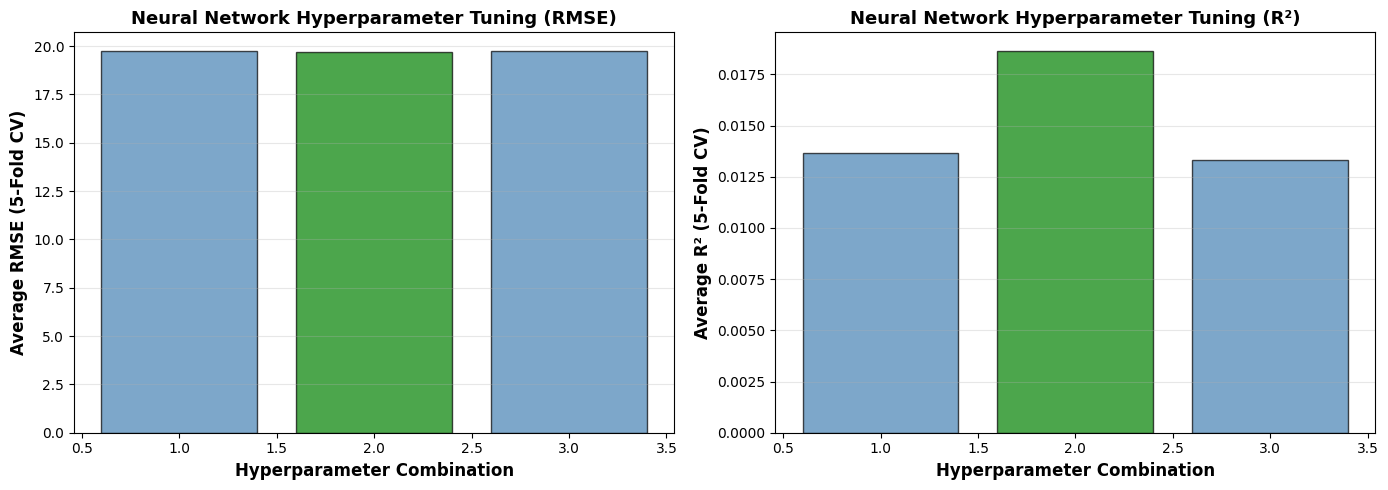

In [18]:
results_df = pd.DataFrame([
    {
        'Combination': i+1,
        'Learning Rate': r['params']['lr'],
        'Hidden 1': r['params']['h1'],
        'Hidden 2': r['params']['h2'],
        'Hidden 3': r['params']['h3'],
        'Avg RMSE': r['avg_rmse'],
        'Avg R²': r['avg_r2'],
        'Std RMSE': r['std_rmse']
    }
    for i, r in enumerate(cv_results)
])

print("HYPERPARAMETER TUNING RESULTS SUMMARY:\n")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
rmse_values = [r['avg_rmse'] for r in cv_results]
colors = ['green' if i == best_idx else 'steelblue' for i in range(len(cv_results))]

ax1 = axes[0]
ax1.bar(range(1, len(rmse_values) + 1), rmse_values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Hyperparameter Combination', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average RMSE (5-Fold CV)', fontsize=12, fontweight='bold')
ax1.set_title('Neural Network Hyperparameter Tuning (RMSE)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# R² comparison
r2_values = [r['avg_r2'] for r in cv_results]

ax2 = axes[1]
ax2.bar(range(1, len(r2_values) + 1), r2_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Hyperparameter Combination', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average R² (5-Fold CV)', fontsize=12, fontweight='bold')
ax2.set_title('Neural Network Hyperparameter Tuning (R²)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X)

# initialize final model with best parameters
final_model = RegressionNeuralNetwork(
    input_dim=X_train_scaled.shape[1],
    hidden_dim1=best_params['h1'],
    hidden_dim2=best_params['h2'],
    hidden_dim3=best_params['h3'],
    dropout_rate=best_params['dropout']
)

# train final model on full training set
print("\nTraining final model on full training set")
train_losses, _ = train_neural_network(
    X_train_scaled, y,
    X_train_scaled, y,
    final_model,
    learning_rate=best_params['lr'],
    epochs=best_params['epochs'],
    batch_size=best_params['batch']
)

print("Final model training completed")


Training final model on full training set


In [ ]:
print(f"\nModel Architecture:")
print(final_model)

print(f"\nTraining Summary:")
print(f"  Input Features: {X_train_scaled.shape}")
print(f"  Training Samples: {len(X)}")
print(f"  Best Learning Rate: {best_params['lr']}")
print(f"  Best Hidden Dimensions: {best_params['h1']}-{best_params['h2']}-{best_params['h3']}")
print(f"  Best Dropout: {best_params['dropout']}")
print(f"  Best Batch Size: {best_params['batch']}")
print(f"  Best Epochs: {best_params['epochs']}")
print(f"  Cross-Validated RMSE: {cv_results[best_idx]['avg_rmse']:.4f}")
print(f"  Cross-Validated R²: {cv_results[best_idx]['avg_r2']:.4f}")